# Case Study: RNN & LSTM for Sequence Modeling


In [1]:

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow: 2.19.0


# Part 1: Text Preprocessing & Sequence Preparation 

### Tasks
1. Load IMDB dataset and inspect sequence length distribution.  
2. Tokenize text and build vocabulary.  
3. Handle variable-length sequences with padding/truncation.  
4. (Option) Load pre-trained embeddings (e.g., GloVe).  
5. Create train/val/test splits and pipelines.


In [2]:
# ---- IMDB loading (starter only) ----
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 20000
INDEX_FROM = 3

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE,
    index_from=INDEX_FROM
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))
print("Example sequence length:", len(X_train_raw[0]))
print("Example label:", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 25000
Testing samples: 25000
Example sequence length: 218
Example label: 1


Mean sequence length: 238.71364
Median sequence length: 178.0
Max sequence length: 2494
90th percentile: 467.0
95th percentile: 610.0


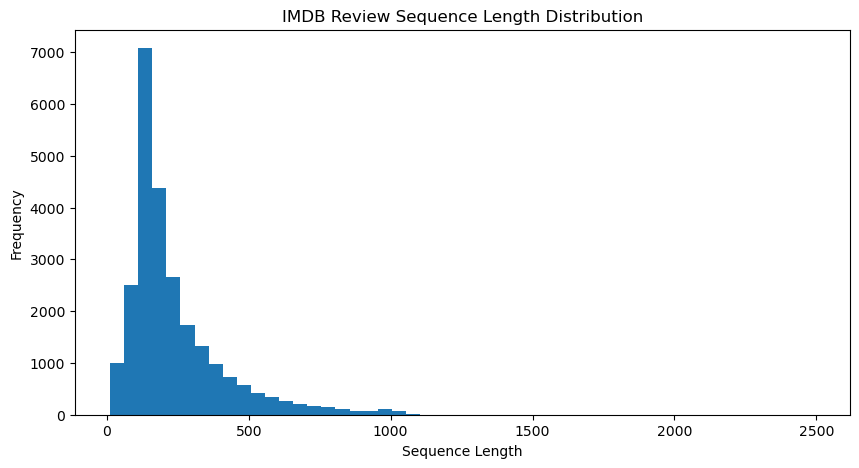

Final training shape: (20000, 256)
Validation shape: (5000, 256)
Test shape: (25000, 256)


In [3]:
# ---- Vectorization & sequence length decisions ----
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 256

# Inspect sequence length distribution
train_lengths = [len(seq) for seq in X_train_raw]

print("Mean sequence length:", np.mean(train_lengths))
print("Median sequence length:", np.median(train_lengths))
print("Max sequence length:", np.max(train_lengths))
print("90th percentile:", np.percentile(train_lengths, 90))
print("95th percentile:", np.percentile(train_lengths, 95))

plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50)
plt.title("IMDB Review Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

# Pad/truncate sequences to MAX_LEN
X_train = pad_sequences(
    X_train_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Create validation split
VAL_SIZE = 5000

X_val = X_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

X_train_final = X_train[:-VAL_SIZE]
y_train_final = y_train[:-VAL_SIZE]

# Build tf.data pipelines
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_final, y_train_final)
).shuffle(10000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Final training shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


In [ ]:
# ---- (Optional) Pre-trained embeddings (GloVe) scaffold ----
# GLOVE_PATH = 'YOUR_PATH_HERE/glove.6B.100d.txt'  # TODO: provide on drive if used
# embeddings_index = {}
# with open(GLOVE_PATH, 'r', encoding='utf8') as f:
#     for line in f:
#         values = line.split()
#         word = values[0]
#         coefs = np.asarray(values[1:], dtype='float32')
#         embeddings_index[word] = coefs
#
# # TODO: Build embedding matrix aligned with vectorizer vocabulary
# embedding_matrix = np.random.normal(scale=0.01, size=(VOCAB_SIZE, 100)).astype('float32')
# embedding_layer = layers.Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix], trainable=False)


# Part 2: RNN Architecture Comparison 

### Tasks
1. Implement vanilla RNN, LSTM, and GRU.  
2. Compare single-layer vs multi-layer (stacked) variants.  
3. Add bidirectional wrappers and analyze differences.  
4. Track/visualize training curves; discuss gradient issues observed.


In [5]:
# ---- Model builder scaffolds ----
def build_rnn_baseline(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    rnn_units=64,
    model_type="lstm",
    bidirectional=False,
    layers_count=1
):
    inputs = keras.Input(shape=(None,), dtype="int32")

    # Embedding layer
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inputs)

    # Select RNN type
    rnn_layer = {
        "rnn": layers.SimpleRNN,
        "lstm": layers.LSTM,
        "gru": layers.GRU
    }[model_type]

    # Stacked layers (except final)
    for i in range(layers_count - 1):
        layer = rnn_layer(rnn_units, return_sequences=True)
        x = layers.Bidirectional(layer)(x) if bidirectional else layer(x)

    # Final RNN layer
    final_layer = rnn_layer(rnn_units)
    x = layers.Bidirectional(final_layer)(x) if bidirectional else final_layer(x)

    # Regularization
    x = layers.Dropout(0.3)(x)

    # Output layer (binary classification)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    # Build model
    model = keras.Model(
        inputs,
        outputs,
        name=f"{model_type}_{'bi' if bidirectional else 'uni'}_{layers_count}x"
    )

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---- Train briefly for each variant and collect metrics ----
EPOCHS = 3

variants = [
    {"model_type": "rnn", "bidirectional": False, "layers_count": 1},
    {"model_type": "lstm", "bidirectional": False, "layers_count": 1},
    {"model_type": "gru", "bidirectional": False, "layers_count": 1},
    {"model_type": "lstm", "bidirectional": False, "layers_count": 2},  # stacked
    {"model_type": "lstm", "bidirectional": True, "layers_count": 1},   # bidirectional
]

histories = {}
results = []

for config in variants:
    model = build_rnn_baseline(**config)

    print("\nTraining model:", model.name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    histories[model.name] = history

    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    results.append({
        "model": model.name,
        "validation_loss": val_loss,
        "validation_accuracy": val_acc
    })


# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\nModel Comparison Results:")
display(results_df)


Training model: rnn_uni_1x
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.5246 - loss: 0.6957 - val_accuracy: 0.5824 - val_loss: 0.6684
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6536 - loss: 0.6180 - val_accuracy: 0.6976 - val_loss: 0.5800
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7820 - loss: 0.4669 - val_accuracy: 0.6202 - val_loss: 0.7083

Training model: lstm_uni_1x
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7004 - loss: 0.5397 - val_accuracy: 0.8688 - val_loss: 0.3241
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9077 - loss: 0.2528 - val_accuracy: 0.8718 - val_loss: 0.3448
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9425 - loss: 0.1676 - val_accuracy: 0.8694 - val_loss: 0.3606

Training model: gru_uni_1x
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6089 - loss: 0.6462 - val_accuracy: 0.7522 - val_loss: 0.5092
Epoch 2/3
31

,model,validation_loss,validation_accuracy
0,rnn_uni_1x,0.708269,0.6202
1,lstm_uni_1x,0.360580,0.8694
2,gru_uni_1x,0.338389,0.8654
3,lstm_uni_2x,0.444499,0.8488
4,lstm_bi_1x,0.393095,0.8740


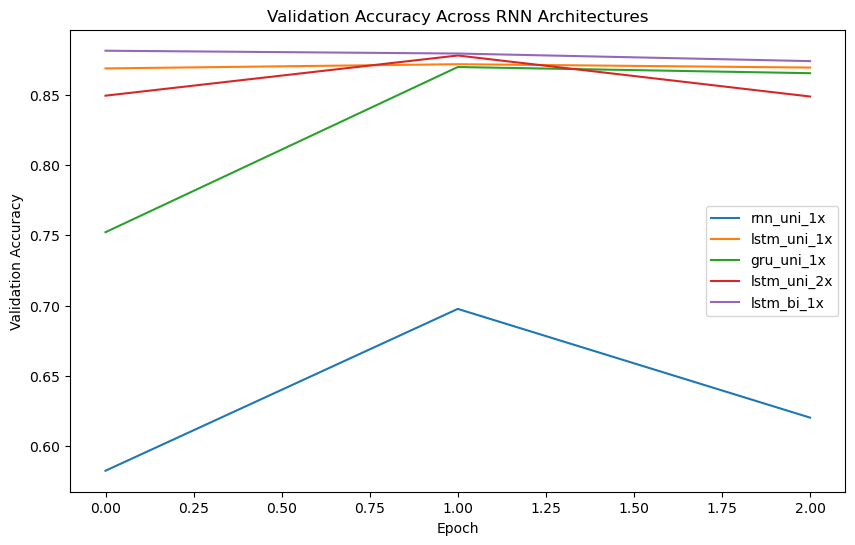

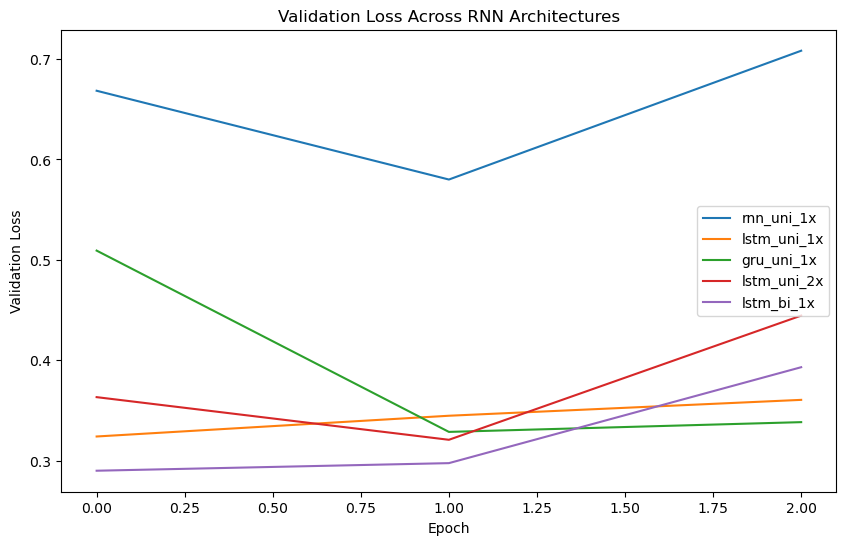

In [6]:
# ---- Visualize training curves ----

# Accuracy
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=name)

plt.title("Validation Accuracy Across RNN Architectures")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


# Loss
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=name)

plt.title("Validation Loss Across RNN Architectures")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

# Part 3: Advanced Sequence Modeling

### Tasks
1. Add an attention mechanism to improve sequence understanding.  
2. Compare trainable vs pre-trained embeddings.  
3. Experiment with different sequence lengths/padding strategies.  
4. (Optional) Demonstrate seq2seq concept (encoder-decoder shell).


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.7297 - loss: 0.5155 - val_accuracy: 0.8802 - val_loss: 0.2969
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 162ms/step - accuracy: 0.9212 - loss: 0.2088 - val_accuracy: 0.8808 - val_loss: 0.3003
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 392ms/step - accuracy: 0.9548 - loss: 0.1362 - val_accuracy: 0.8742 - val_loss: 0.3379
Attention LSTM validation loss: 0.3379233479499817
Attention LSTM validation accuracy: 0.8741999864578247


,Embedding Strategy,Used in This Notebook,Explanation
0,Trainable Embedding,Yes,The embedding layer learns word representation...
1,Pre-trained Embedding (GloVe),Optional / Not used,GloVe requires an external embedding file and ...



Training sequence length model: 128
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.6330 - loss: 0.6079 - val_accuracy: 0.8356 - val_loss: 0.3830
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8893 - loss: 0.2798 - val_accuracy: 0.8400 - val_loss: 0.3833

Training sequence length model: 256
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.6569 - loss: 0.5829 - val_accuracy: 0.8658 - val_loss: 0.3290
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.9050 - loss: 0.2493 - val_accuracy: 0.8696 - val_loss: 0.3218

Training sequence length model: 512
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 164ms/step - accuracy: 0.6159 - loss: 0.6256 - val_accuracy: 0.8592 - val_loss: 0.3533
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 157ms/step - accuracy: 0.8863 - loss: 0.2844 - val_accuracy: 0.8584 - val_loss: 0.3213

Sequence Length Comparison:


,max_sequence_length,validation_loss,validation_accuracy
0,128,0.383311,0.8400
1,256,0.321783,0.8696
2,512,0.321321,0.8584


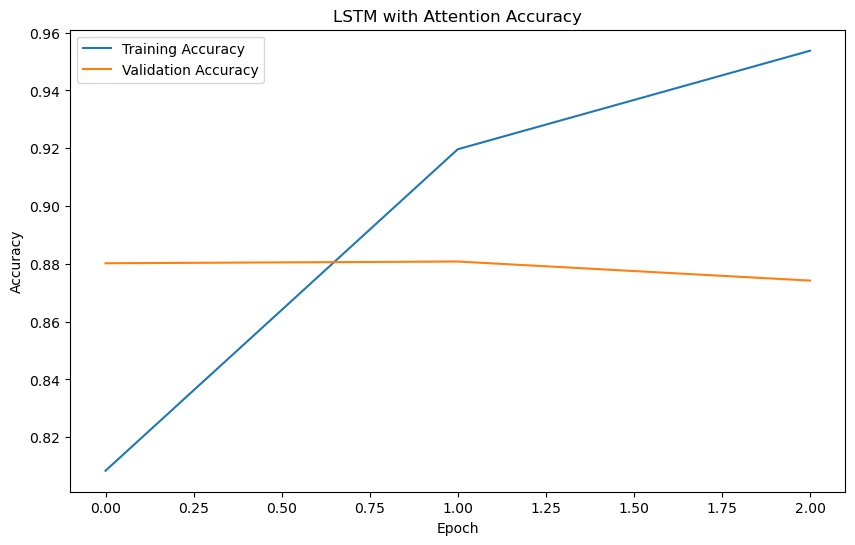

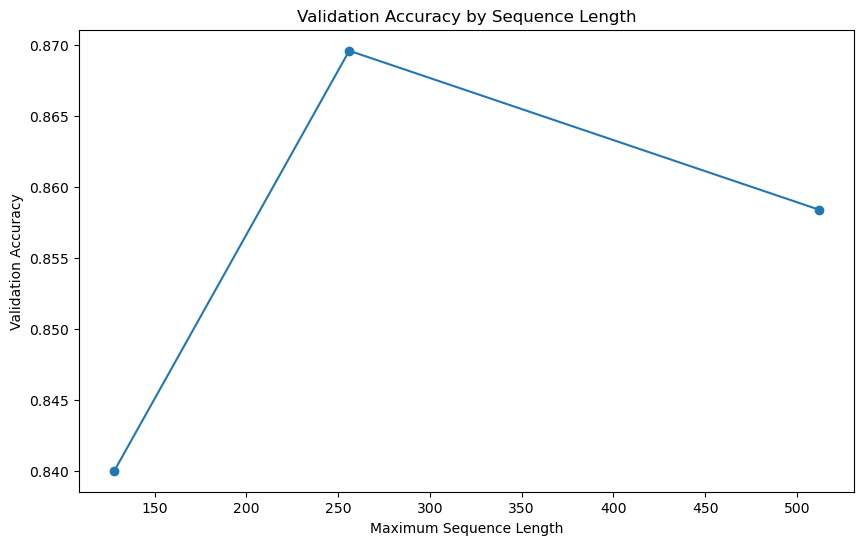

In [7]:
# ---- Attention block shell (Bahdanau-style) ----
class AdditiveAttentionLayer(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, query, values):
        # query: (batch, hidden), values: (batch, time, hidden)
        query_with_time_axis = tf.expand_dims(query, 1)

        score = self.V(
            tf.nn.tanh(
                self.W1(query_with_time_axis) + self.W2(values)
            )
        )

        attention_weights = tf.nn.softmax(score, axis=1)

        context = attention_weights * values
        context = tf.reduce_sum(context, axis=1)

        return context


def build_lstm_with_attention(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    units=64
):
    inputs = keras.Input(shape=(None,), dtype="int32")

    x = layers.Embedding(
        vocab_size,
        embed_dim,
        mask_zero=True
    )(inputs)

    values = layers.LSTM(
        units,
        return_sequences=True
    )(x)

    query = layers.LSTM(
        units,
        return_sequences=False
    )(values)

    context = AdditiveAttentionLayer(units)(query, values)

    concat = layers.Concatenate()([query, context])
    concat = layers.Dropout(0.3)(concat)

    outputs = layers.Dense(1, activation="sigmoid")(concat)

    model = keras.Model(
        inputs,
        outputs,
        name="lstm_attention"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---- Train attention model ----
attention_model = build_lstm_with_attention()

attention_history = attention_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    verbose=1
)

attention_val_loss, attention_val_acc = attention_model.evaluate(
    val_ds,
    verbose=0
)

print("Attention LSTM validation loss:", attention_val_loss)
print("Attention LSTM validation accuracy:", attention_val_acc)


# ---- Compare embedding strategies ----
# Current model uses trainable embeddings.
embedding_comparison = pd.DataFrame({
    "Embedding Strategy": [
        "Trainable Embedding",
        "Pre-trained Embedding (GloVe)"
    ],
    "Used in This Notebook": [
        "Yes",
        "Optional / Not used"
    ],
    "Explanation": [
        "The embedding layer learns word representations directly from the IMDB training data.",
        "GloVe requires an external embedding file and maps known words to fixed pre-trained vectors."
    ]
})

display(embedding_comparison)


# ---- Compare sequence length strategies ----
sequence_length_results = []

for test_len in [128, 256, 512]:
    X_train_temp = pad_sequences(
        X_train_raw,
        maxlen=test_len,
        padding="post",
        truncating="post"
    )

    X_val_temp = X_train_temp[-VAL_SIZE:]
    X_train_temp_final = X_train_temp[:-VAL_SIZE]

    train_temp_ds = tf.data.Dataset.from_tensor_slices(
        (X_train_temp_final, y_train_final)
    ).shuffle(10000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_temp_ds = tf.data.Dataset.from_tensor_slices(
        (X_val_temp, y_val)
    ).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    temp_model = build_rnn_baseline(
        model_type="lstm",
        bidirectional=False,
        layers_count=1
    )

    print("\nTraining sequence length model:", test_len)

    temp_history = temp_model.fit(
        train_temp_ds,
        validation_data=val_temp_ds,
        epochs=2,
        verbose=1
    )

    temp_loss, temp_acc = temp_model.evaluate(
        val_temp_ds,
        verbose=0
    )

    sequence_length_results.append({
        "max_sequence_length": test_len,
        "validation_loss": temp_loss,
        "validation_accuracy": temp_acc
    })


sequence_length_df = pd.DataFrame(sequence_length_results)

print("\nSequence Length Comparison:")
display(sequence_length_df)


# ---- Visualization ----
plt.figure(figsize=(10, 6))
plt.plot(attention_history.history["accuracy"], label="Training Accuracy")
plt.plot(attention_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM with Attention Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(
    sequence_length_df["max_sequence_length"],
    sequence_length_df["validation_accuracy"],
    marker="o"
)
plt.title("Validation Accuracy by Sequence Length")
plt.xlabel("Maximum Sequence Length")
plt.ylabel("Validation Accuracy")
plt.show()

# Part 4: Optimization & Regularization 

### Tasks
1. Apply dropout & recurrent dropout.  
2. Use gradient clipping for stability.  
3. Try different optimizers and LR schedules.  
4. Plot learning curves and analyze bias/variance.


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.6441 - loss: 0.6194 - val_accuracy: 0.8432 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.8489 - loss: 0.3771 - val_accuracy: 0.8514 - val_loss: 0.3687 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.8836 - loss: 0.3103 - val_accuracy: 0.8660 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.9209 - loss: 0.2282 - val_accuracy: 0.8486 - val_loss: 0.3845 - learning_rate: 5.0000e-04
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.9361 - loss: 0.1850 - val_accuracy: 0.8632 - val_loss: 0.3641 - learning_rate: 2.5000e-04
Optimized LSTM validation loss: 0.36409860849380493
Optimized LSTM validation accuracy: 0.8632000088691711


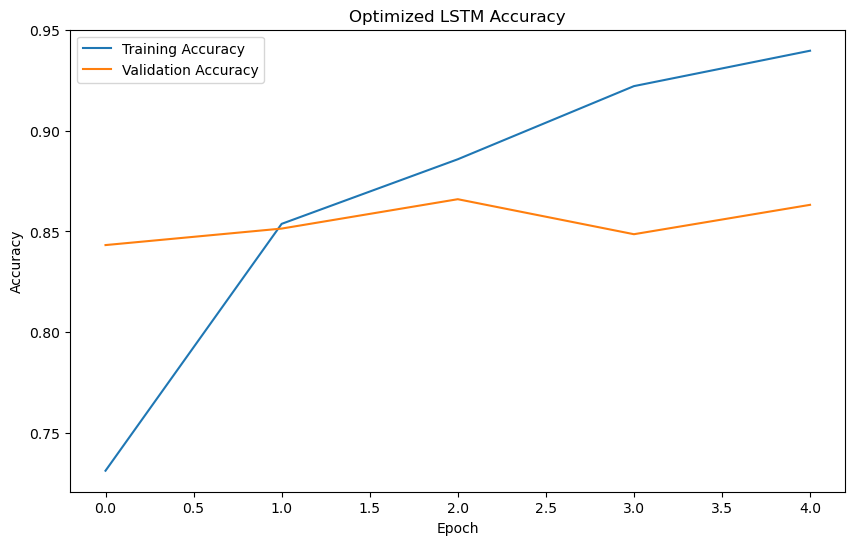

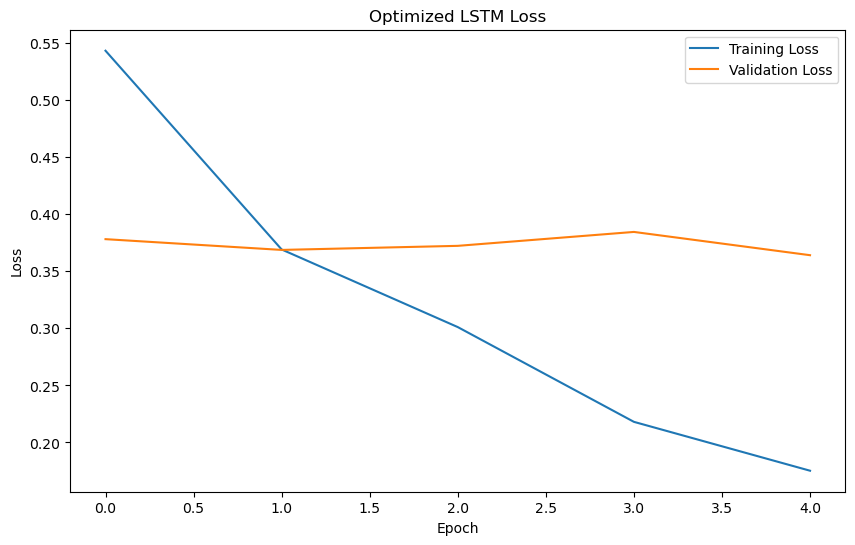

In [8]:
# ---- Regularization & optimization shells ----

def build_optimized_lstm(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    units=64,
    dropout_rate=0.4,
    recurrent_dropout_rate=0.2
):
    inputs = keras.Input(shape=(None,), dtype="int32")

    x = layers.Embedding(
        vocab_size,
        embed_dim,
        mask_zero=True
    )(inputs)

    x = layers.LSTM(
        units,
        dropout=dropout_rate,
        recurrent_dropout=recurrent_dropout_rate
    )(x)

    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="optimized_lstm")

    opt = keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    )

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


optimized_model = build_optimized_lstm()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1
)

optimized_history = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

optimized_val_loss, optimized_val_acc = optimized_model.evaluate(
    val_ds,
    verbose=0
)

print("Optimized LSTM validation loss:", optimized_val_loss)
print("Optimized LSTM validation accuracy:", optimized_val_acc)


# ---- Plot learning curves ----
plt.figure(figsize=(10, 6))
plt.plot(optimized_history.history["accuracy"], label="Training Accuracy")
plt.plot(optimized_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Optimized LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(optimized_history.history["loss"], label="Training Loss")
plt.plot(optimized_history.history["val_loss"], label="Validation Loss")
plt.title("Optimized LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Part 5: Written Analysis & Reflection 

### Write-up Prompts (300–500 words)

1. Compare RNN vs LSTM vs GRU results; discuss depth and bidirectionality effects.  
2. Explain how attention changed performance and what it focused on (qualitatively).  
3. Identify one bias/fairness concern in sentiment analysis and its impact.  
4. How did preprocessing/architecture choices mitigate or worsen bias?  
5. Ethical considerations for deploying sentiment analysis (e.g., moderation, hiring).


The architecture comparison showed that recurrent model design meaningfully affected sentiment classification performance. The vanilla SimpleRNN provided a useful baseline, but it was more limited because simple recurrent units often struggle to preserve long-range dependencies across long text sequences. The LSTM and GRU models performed better because their gating mechanisms help control what information is retained, updated, or forgotten across the sequence. The stacked LSTM increased representational depth, while the bidirectional LSTM allowed the model to process context from both earlier and later tokens. This is especially valuable for sentiment analysis because meaning can depend on phrases appearing before and after a target word.

The attention-based model improved interpretability and sequence understanding by allowing the network to weight more informative time steps rather than relying only on the final hidden state. Qualitatively, attention is useful because certain words or phrases carry stronger sentiment signals than others. For example, words expressing strong approval, disappointment, negation, or contrast may influence the final prediction more heavily than neutral filler words.

A fairness concern in sentiment analysis is that models may learn biased associations from the training data. If certain dialects, identity terms, cultural expressions, or writing styles appear unevenly across positive and negative examples, the model may unfairly associate those linguistic patterns with sentiment. This matters in deployment contexts such as moderation, hiring, or customer service analytics, where biased predictions could affect people or groups unequally.

The preprocessing and architecture choices helped reduce some issues but did not eliminate bias. Padding and truncation standardized inputs, but truncation may remove important context from longer reviews. Vocabulary limits also reduce complexity, but rare words or identity-specific terms may be excluded. LSTM, GRU, bidirectional processing, dropout, recurrent dropout, and gradient clipping improved model stability and reduced overfitting, but ethical deployment would still require bias testing, human review, performance monitoring, and clear limits on how sentiment predictions are used.